In [1]:
import kagglehub
import shutil
import os

# Download the dataset (cached path)
cached_path = kagglehub.dataset_download("roudranildas/chicken-images-classification-dataset")

# Define target path (working directory)
target_path = "/content/"

# Copy from cache to working directory
shutil.copytree(cached_path, target_path, dirs_exist_ok=True)

# New structure path
base_dir = "/content/organized-data"
splits = ['train', 'val', 'test']
classes = ['chicken', 'duck']

# Create new folders
for split in splits:

    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Copy files
for cls in classes:
    src_root = f"/content/data/{cls}-images/data"
    for split in splits:
        src = os.path.join(src_root, split)
        dst = os.path.join(base_dir, split, cls)
        for file in os.listdir(src):
            shutil.copy(os.path.join(src, file), dst)

100%|██████████| 43.0M/43.0M [00:00<00:00, 191MB/s]

Extracting files...


## Importing necessary libraries

In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Load dataset

In [4]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_dir = "/content/organized-data"

train_ds = datasets.ImageFolder(root=os.path.join(base_dir, 'train'), transform=transform)
val_ds = datasets.ImageFolder(root=os.path.join(base_dir, 'val'), transform=transform)
test_ds = datasets.ImageFolder(root=os.path.join(base_dir, 'test'), transform=transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print("Classes:", train_ds.classes)

Classes: ['chicken', 'duck']


## Load the pre- trained model

In [5]:
model = models.resnet18(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Chicken vs Duck
for param in model.parameters():
    param.requires_grad = False  # freeze all layers

# Unfreeze the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


In [6]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
def evaluate(model, val_loader):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

## Training

In [8]:
train_losses = []
val_losses = []

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    # Store for graph
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)

    # Print every 5 epochs (or final epoch)
    if (epoch + 1) % 5 == 0 or (epoch + 1) == num_epochs:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%\n")

Epoch [5/50]
Train Loss: 0.3313 | Val Loss: 0.3448 | Val Acc: 83.23%

Epoch [10/50]
Train Loss: 0.2383 | Val Loss: 0.2920 | Val Acc: 86.34%

Epoch [15/50]
Train Loss: 0.2020 | Val Loss: 0.2494 | Val Acc: 89.44%

Epoch [20/50]
Train Loss: 0.2037 | Val Loss: 0.2615 | Val Acc: 88.82%

Epoch [25/50]
Train Loss: 0.1624 | Val Loss: 0.2282 | Val Acc: 89.44%

Epoch [30/50]
Train Loss: 0.1900 | Val Loss: 0.2271 | Val Acc: 90.68%

Epoch [35/50]
Train Loss: 0.1729 | Val Loss: 0.2390 | Val Acc: 89.44%

Epoch [40/50]
Train Loss: 0.1777 | Val Loss: 0.2205 | Val Acc: 91.30%

Epoch [45/50]
Train Loss: 0.1307 | Val Loss: 0.2021 | Val Acc: 91.30%

Epoch [50/50]
Train Loss: 0.1717 | Val Loss: 0.2029 | Val Acc: 91.93%



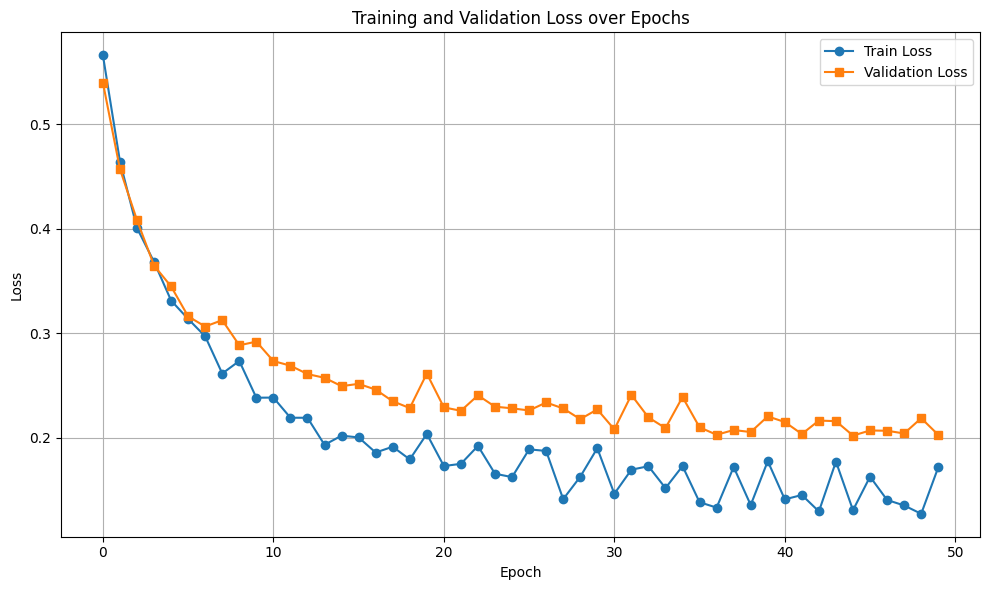

In [9]:
# Plotting after training
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='s')
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluate the data on test set

In [10]:
def generate_classification_report(model, dataloader, class_names, device, name=""):
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                images, labels = batch
            else:
                images = batch
                labels = None  # Just in case, unlikely in this use case

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            preds_list.extend(preds.cpu().tolist())
            labels_list.extend(labels.cpu().tolist())

    print(f"\n📊 Classification Report - {name} Set\n")
    print(classification_report(labels_list, preds_list, target_names=class_names))

In [11]:
class_names = train_ds.classes
generate_classification_report(model, test_loader, class_names, device, name="Test")


📊 Classification Report - Test Set

              precision    recall  f1-score   support

     chicken       0.99      0.89      0.94       172
        duck       0.94      0.99      0.97       310

    accuracy                           0.96       482
   macro avg       0.96      0.94      0.95       482
weighted avg       0.96      0.96      0.96       482

